# **1. Perkenalan Dataset**


Dataset Titanic berisi data penumpang kapal Titanic, seperti kelas tiket, jenis kelamin, umur, jumlah keluarga, tarif, dan status keselamatan. Dataset ini digunakan untuk membangun model klasifikasi yang memprediksi apakah seorang penumpang selamat atau tidak.

**Sumber Dataset**: https://www.kaggle.com/datasets/yasserh/titanic-dataset


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# **3. Memuat Dataset**

In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()

In [3]:
# Ubah permission
!chmod 600 kaggle.json

In [4]:
# Download dataset
!kaggle datasets download -d yasserh/titanic-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
100% 22.0k/22.0k [00:00<00:00, 34.7MB/s]



In [5]:
# Ekstrak zip
!unzip -q titanic-dataset.zip -d /content/titanic_raw

In [6]:
# Menghapus zip
!rm titanic-dataset.zip

# **4. Exploratory Data Analysis (EDA)**

In [7]:
# Menampilkan datafrane
df = pd.read_csv("titanic_raw/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Informasi dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


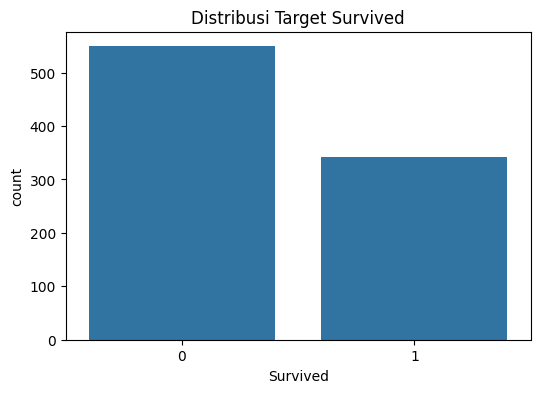

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived')
plt.title("Distribusi Target Survived")
plt.show()

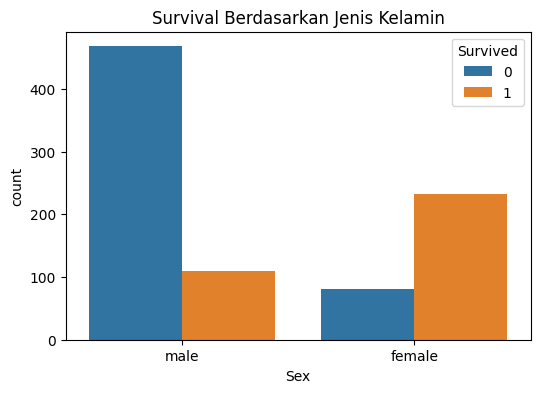

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival Berdasarkan Jenis Kelamin")
plt.show()

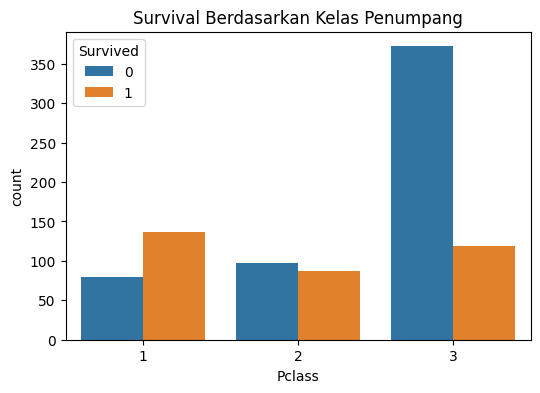

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Survival Berdasarkan Kelas Penumpang")
plt.show()

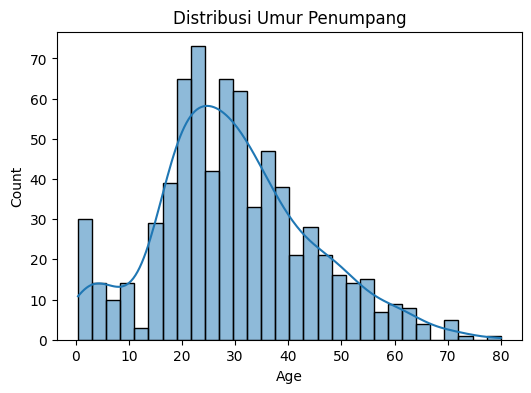

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribusi Umur Penumpang")
plt.show()

# **5. Data Preprocessing**

## Data Cleaning

In [15]:
# Mengecek missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
# Menghapus missing values
df = df.dropna()

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
# Menghapus data duplikat
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [18]:
# Menghapus kolom yang tidak digunakan
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
1,1,1,female,38.0,1,0,71.2833,C
3,1,1,female,35.0,1,0,53.1000,S
6,0,1,male,54.0,0,0,51.8625,S
10,1,3,female,4.0,1,1,16.7000,S
11,1,1,female,58.0,0,0,26.5500,S


In [19]:
label_encoder = LabelEncoder()

df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
1,1,1,0,38.0,1,0,71.2833,0
3,1,1,0,35.0,1,0,53.1000,2
6,0,1,1,54.0,0,0,51.8625,2
10,1,3,0,4.0,1,1,16.7000,2
11,1,1,0,58.0,0,0,26.5500,2


In [20]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Data Augmentation

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data validation:", X_val.shape[0])
print("Jumlah data test:", X_test.shape[0])

Jumlah data train: 146
Jumlah data validation: 18
Jumlah data test: 19


In [23]:
import os

os.makedirs("preprocessing/titanic_preprocessing", exist_ok=True)

pd.DataFrame(X_train).to_csv("preprocessing/titanic_preprocessing/X_train.csv", index=False)
pd.DataFrame(X_val).to_csv("preprocessing/titanic_preprocessing/X_val.csv", index=False)
pd.DataFrame(X_test).to_csv("preprocessing/titanic_preprocessing/X_test.csv", index=False)

pd.DataFrame(y_train).to_csv("preprocessing/titanic_preprocessing/y_train.csv", index=False)
pd.DataFrame(y_val).to_csv("preprocessing/titanic_preprocessing/y_val.csv", index=False)
pd.DataFrame(y_test).to_csv("preprocessing/titanic_preprocessing/y_test.csv", index=False)